# Convolutional Hybrid QNN — Genomic Dataset (5-Class)
**Architecture:** CNN feature extractor → Classical skip branch + Quantum circuit → PQ-FiLM fusion → 5-class softmax

- Input: 16×512 genomic feature matrix from DNA sequence (one-hot k-mer encoding)
- Quantum: AngleEmbedding + BasicEntanglerLayers (4 qubits, 4 layers)
- Fusion: FiLM modulation + gating (QuantumGuidedFusion)
- Labels: Genomic Class 0-4 (5 biological species/categories)


In [1]:
import os
import random
import copy
import json
import time
import math
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ==========================================
# 1. STRICT REPRODUCIBILITY SETUP
# ==========================================
SEED = 42

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device} | Seed locked to: {SEED}')

Using device: cuda | Seed locked to: 42


In [2]:
# ==========================================
# 2. LOAD GENOMIC DATASET (synthetic for demo)
# ==========================================

# Try to load using qp.data interface, fallback to synthetic data
try:
    # Attempt to import qp and load genomic data
    import qp
    print("Loading genomic dataset via qp.data.load()...")
    genomic_data = qp.data.load("other", name="genomic")
    X_genomic_raw = genomic_data['X']
    y_genomic_raw = genomic_data['y']
    class_names = genomic_data.get('class_names', [f'Genomic_Class_{i}' for i in range(len(np.unique(y_genomic_raw)))])
    print(f"Genomic data loaded: X shape {X_genomic_raw.shape}, y shape {y_genomic_raw.shape}")
except (ImportError, Exception) as e:
    print(f"Note: qp module not available ({e}). Generating synthetic genomic dataset...")
    
    # ========== SYNTHETIC GENOMIC DATA GENERATION ==========
    # Simulate DNA sequences from 5 genomic classes (e.g., species/variants)
    # Each sequence is encoded as one-hot features (4 DNA bases: A, T, G, C)
    
    N_CLASSES = 5
    SAMPLES_PER_CLASS = 300  # Total 3000 samples across 5 classes
    SEQ_LENGTH = 8192  # Simulated sequence length
    
    DNA_BASES = ['A', 'T', 'G', 'C']
    
    def generate_genomic_sequence(class_id, length=SEQ_LENGTH):
        """Generate synthetic DNA sequence with class-specific biases."""
        # Add class-specific bias to make classes distinguishable
        base_probs = np.array([0.25, 0.25, 0.25, 0.25])
        class_bias = np.array([0.40, 0.20, 0.20, 0.20]) if class_id == 0 else \
                     np.array([0.20, 0.40, 0.20, 0.20]) if class_id == 1 else \
                     np.array([0.20, 0.20, 0.40, 0.20]) if class_id == 2 else \
                     np.array([0.20, 0.20, 0.20, 0.40]) if class_id == 3 else \
                     np.array([0.30, 0.30, 0.20, 0.20])
        
        bases = np.random.choice(4, size=length, p=class_bias)
        return bases
    
    def encode_sequence_onehot(seq, k_mer=4):
        """Convert DNA sequence to one-hot k-mer features (shape: n_kmers, 4^k_mer)."""
        n_kmers = len(seq) - k_mer + 1
        features = []
        for i in range(n_kmers):
            kmer = seq[i:i+k_mer]
            # Simple k-mer encoding: treat as base-4 number
            kmer_val = kmer[0] + kmer[1]*4 + kmer[2]*16 + kmer[3]*64
            onehot = np.zeros(256, dtype=np.float32)  # 4^4 = 256
            onehot[kmer_val] = 1.0
            features.append(onehot)
        return np.array(features)
    
    # Generate synthetic genomic data
    X_all_list = []
    y_all_list = []
    
    for class_id in range(N_CLASSES):
        for sample_idx in range(SAMPLES_PER_CLASS):
            seq = generate_genomic_sequence(class_id)
            features = encode_sequence_onehot(seq, k_mer=4)
            # Downsample to match spectrogram shape: take every 16th k-mer
            features_downsampled = features[::16][:512]  # Keep up to 512 features
            # Pad if necessary
            if len(features_downsampled) < 512:
                pad_width = ((0, 512 - len(features_downsampled)), (0, 0))
                features_downsampled = np.pad(features_downsampled, pad_width, mode='constant')
            X_all_list.append(features_downsampled[:512])
            y_all_list.append(class_id)
    
    X_genomic_raw = np.stack(X_all_list).astype(np.float32)  # (N, 512, 256)
    y_genomic_raw = np.array(y_all_list, dtype=np.int64)
    class_names = [f'Genomic_Species_{i}' for i in range(N_CLASSES)]
    
    print(f"Synthetic genomic dataset generated: X shape {X_genomic_raw.shape}, y shape {y_genomic_raw.shape}")

# Dataset configuration
BASE_DIR = Path('/home/sammarv/quantum_corrosion')
OUT_DIR = BASE_DIR / 'results/genomic_conv_hybrid_qnn'
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_CLASSES = len(np.unique(y_genomic_raw))
LABEL_NAMES = class_names

print(f'Number of classes: {N_CLASSES}')
print(f'Class labels: {LABEL_NAMES}')
print(f'Dataset shape: {X_genomic_raw.shape}  labels: {np.bincount(y_genomic_raw)}')

Note: qp module not available (No module named 'qp'). Generating synthetic genomic dataset...
Synthetic genomic dataset generated: X shape (1500, 512, 256), y shape (1500,)
Number of classes: 5
Class labels: ['Genomic_Species_0', 'Genomic_Species_1', 'Genomic_Species_2', 'Genomic_Species_3', 'Genomic_Species_4']
Dataset shape: (1500, 512, 256)  labels: [300 300 300 300 300]


In [3]:
# ==========================================
# 3. FEATURE PREPARATION (NO AUGMENTATION)
# ==========================================
print("Preparing genomic dataset WITHOUT augmentation...")
# Use raw genomic features directly (no augmentation)
X_all = X_genomic_raw.astype(np.float32)
y_all = y_genomic_raw.astype(np.int64)

print(f'Dataset without augmentation: {X_all.shape}  labels: {np.bincount(y_all)}')

Preparing genomic dataset WITHOUT augmentation...
Dataset without augmentation: (1500, 512, 256)  labels: [300 300 300 300 300]


In [4]:
# ==========================================
# 4. PREPROCESSING & RESHAPING FOR CNN
# ==========================================

# Current shape: (N, 512, 256) - need to reshape to (N, 1, 16, 512) for Conv2d
# Strategy: (512, 256) -> aggregate to (16, 512) by reshaping and pooling
N, feat_len, feat_dim = X_all.shape
print(f'Original features shape: {X_all.shape}')

# Reshape strategy: (512, 256) -> (16, 32, 256) -> aggregate -> (16, 512)
X_reshaped_list = []
for i in range(len(X_all)):
    feat = X_all[i]  # (512, 256)
    # Reshape 512 features to 16 stacks of 32 features each
    feat_stacked = feat.reshape(16, 32, 256)  # (16, 32, 256)
    # Reshape 256 dim to 16 groups of 16, then average across the groups
    feat_pooled = feat_stacked.reshape(16, 32, 16, 16).mean(axis=3)  # (16, 32, 16)
    # Flatten to (16, 512)
    feat_final = feat_pooled.reshape(16, 512)  # (16, 512)
    X_reshaped_list.append(feat_final)

X_reshaped = np.stack(X_reshaped_list).astype(np.float32)  # (N, 16, 512)

# Standardize features
N, H, W = X_reshaped.shape
X_flat = X_reshaped.reshape(N, -1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(N, H, W).astype(np.float32)

# Train/test split with stratification
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled, y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print(f'Train: {X_train_np.shape}  Test: {X_test_np.shape}')
print(f'Train class counts: {np.bincount(y_train_np)}')
print(f'Test  class counts: {np.bincount(y_test_np)}')

# Reshape to (N, 1, 16, 512) for Conv2d
X_train_t = torch.tensor(X_train_np[:, None, :, :], dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.long)
X_test_t  = torch.tensor(X_test_np[:, None, :, :], dtype=torch.float32)
y_test_t  = torch.tensor(y_test_np, dtype=torch.long)

batch_size = 32
_n_workers = min(4, os.cpu_count() or 1)
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=_n_workers,
    pin_memory=True,
    persistent_workers=True,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False,
    num_workers=_n_workers,
    pin_memory=True,
    persistent_workers=True,
)

print(f'\nbatch_size={batch_size}  train_batches={len(train_loader)}  test_batches={len(test_loader)}')

Original features shape: (1500, 512, 256)
Train: (1200, 16, 512)  Test: (300, 16, 512)
Train class counts: [240 240 240 240 240]
Test  class counts: [60 60 60 60 60]

batch_size=32  train_batches=37  test_batches=10


In [5]:
# ==========================================
# 5. QUANTUM NODE SETUP
# ==========================================
n_qubits = 4
n_layers = 4

def _make_quantum_device(n_q):
    try:
        dev = qml.device('lightning.gpu', wires=n_q)
        print(f'Quantum device: {dev.name}')
        return dev, 'adjoint'
    except Exception:
        pass
    dev = qml.device('default.qubit', wires=n_q)
    print(f'Quantum device: {dev.name}')
    return dev, 'backprop'

dev, diff_method = _make_quantum_device(n_qubits)

weight_shapes = {'weights': (n_layers, n_qubits)}

@qml.qnode(dev, interface='torch', diff_method=diff_method)
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class BatchedQuantumLayer(nn.Module):
    """Efficient batched quantum layer."""
    def __init__(self, n_l, n_q, q_node):
        super().__init__()
        self.n_qubits = n_q
        self.qnode = q_node
        self.weights = nn.Parameter(
            torch.empty(n_l, n_q).uniform_(-np.pi, np.pi)
        )

    def forward(self, x):
        B = x.shape[0]
        out = self.qnode(x, self.weights)
        return out.float().view(self.n_qubits, B).t().contiguous()

Quantum device: Default qubit PennyLane plugin


In [6]:
# ==========================================
# 6. MODEL ARCHITECTURE
# ==========================================

class QuantumGuidedFusion(nn.Module):
    """FiLM modulation with gating for quantum-guided feature fusion."""
    def __init__(self, c_dim=64, q_dim=4, n_classes=5):
        super().__init__()
        self.film_net = nn.Sequential(
            nn.Linear(q_dim, 32),
            nn.GELU(),
            nn.Linear(32, c_dim * 2)
        )
        self.gate = nn.Sequential(
            nn.Linear(c_dim + q_dim, c_dim),
            nn.Sigmoid()
        )
        self.classifier = nn.Linear(c_dim, n_classes)

    def forward(self, c, q):
        film_params = self.film_net(q)
        gamma, beta = torch.chunk(film_params, 2, dim=1)
        c_mod = c * (gamma + 1.0) + beta
        gate_val = self.gate(torch.cat([c_mod, q], dim=1))
        fused_features = gate_val * c_mod + (1 - gate_val) * c
        return self.classifier(fused_features)


class ConvolutionalHybridQNN(nn.Module):
    """Hybrid CNN-Quantum model for genomic classification."""
    def __init__(self, n_cls=N_CLASSES, dropout_cnn=0.2350, dropout_skip=0.2012):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(32 * 4 * 128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_cnn)
        )
        self.qnn_proj = nn.Sequential(
            nn.Linear(256, n_qubits),
            nn.Sigmoid()
        )
        self.qnn = BatchedQuantumLayer(n_layers, n_qubits, qnode)
        
        self.classical_skip = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_skip),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_skip)
        )
        self.fusion_module = QuantumGuidedFusion(c_dim=64, q_dim=n_qubits, n_classes=n_cls)

    def forward(self, x):
        features = self.cnn(x)
        qbn_input = self.qnn_proj(features) * (2.0 * np.pi)
        q_feats = self.qnn(qbn_input)
        c_feats = self.classical_skip(features)
        return self.fusion_module(c_feats, q_feats)


model = ConvolutionalHybridQNN().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')

# Smoke test
with torch.no_grad():
    _x = X_train_t[:2].to(device)
    _out = model(_x)
    print(f'Forward OK — output shape: {_out.shape}  (expect [2, {N_CLASSES}])')

Trainable params: 4,251,289
Forward OK — output shape: torch.Size([2, 5])  (expect [2, 5])


In [7]:
# ==========================================
# 7. TRAINING LOOP
# ==========================================
epochs = 100
patience = 12

class_counts = np.bincount(y_train_np)
cw_vals = 1.0 / class_counts.astype(np.float32)
cw_vals = cw_vals / cw_vals.sum() * N_CLASSES
loss_weights = torch.tensor(cw_vals, dtype=torch.float32).to(device)
print('Class weights:', [f'{w:.4f}' for w in cw_vals.tolist()])

lr = 0.00079146
weight_decay = 1.11589e-06

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss(weight=loss_weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=6)

print('\n' + '='*65)
print('STARTING TRAINING — Convolutional Hybrid QNN (Genomic 5-class)')
print('='*65)

best_f1 = 0.0
best_loss = float('inf')
epochs_no_impr = 0
best_weights = None
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(inputs)
        loss = criterion(out, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    running_val_loss = 0.0
    all_preds, all_tgts = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            out = model(inputs)
            loss = criterion(out, targets)
            running_val_loss += loss.item() * inputs.size(0)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_tgts.extend(targets.cpu().numpy())
    val_loss = running_val_loss / len(test_loader.dataset)

    acc = accuracy_score(all_tgts, all_preds)
    val_f1 = f1_score(all_tgts, all_preds, average='macro', zero_division=0)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_loss = val_loss
        epochs_no_impr = 0
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, OUT_DIR / 'conv_hybrid_qnn_best.pt')
    else:
        epochs_no_impr += 1

    if epochs_no_impr >= patience:
        print(f'\nEarly Stopping triggered at epoch {epoch+1}.')
        break

print(f'\nBest Val F1: {best_f1:.4f}')

Class weights: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']

STARTING TRAINING — Convolutional Hybrid QNN (Genomic 5-class)
Epoch 001 | Train Loss: 0.7357 | Val Loss: 0.1677 | Val Acc: 0.9167 | Val F1: 0.9105
Epoch 002 | Train Loss: 0.0967 | Val Loss: 0.1311 | Val Acc: 0.9467 | Val F1: 0.9451
Epoch 003 | Train Loss: 0.0249 | Val Loss: 0.1043 | Val Acc: 0.9567 | Val F1: 0.9560
Epoch 004 | Train Loss: 0.0182 | Val Loss: 0.0730 | Val Acc: 0.9700 | Val F1: 0.9694
Epoch 005 | Train Loss: 0.0123 | Val Loss: 0.1020 | Val Acc: 0.9600 | Val F1: 0.9595
Epoch 006 | Train Loss: 0.0323 | Val Loss: 0.0906 | Val Acc: 0.9733 | Val F1: 0.9729
Epoch 007 | Train Loss: 0.0209 | Val Loss: 0.1117 | Val Acc: 0.9567 | Val F1: 0.9560
Epoch 008 | Train Loss: 0.0210 | Val Loss: 0.1800 | Val Acc: 0.9300 | Val F1: 0.9291
Epoch 009 | Train Loss: 0.0122 | Val Loss: 0.0967 | Val Acc: 0.9733 | Val F1: 0.9730
Epoch 010 | Train Loss: 0.0205 | Val Loss: 0.2303 | Val Acc: 0.9367 | Val F1: 0.9332
Epoch 011 | Train Lo

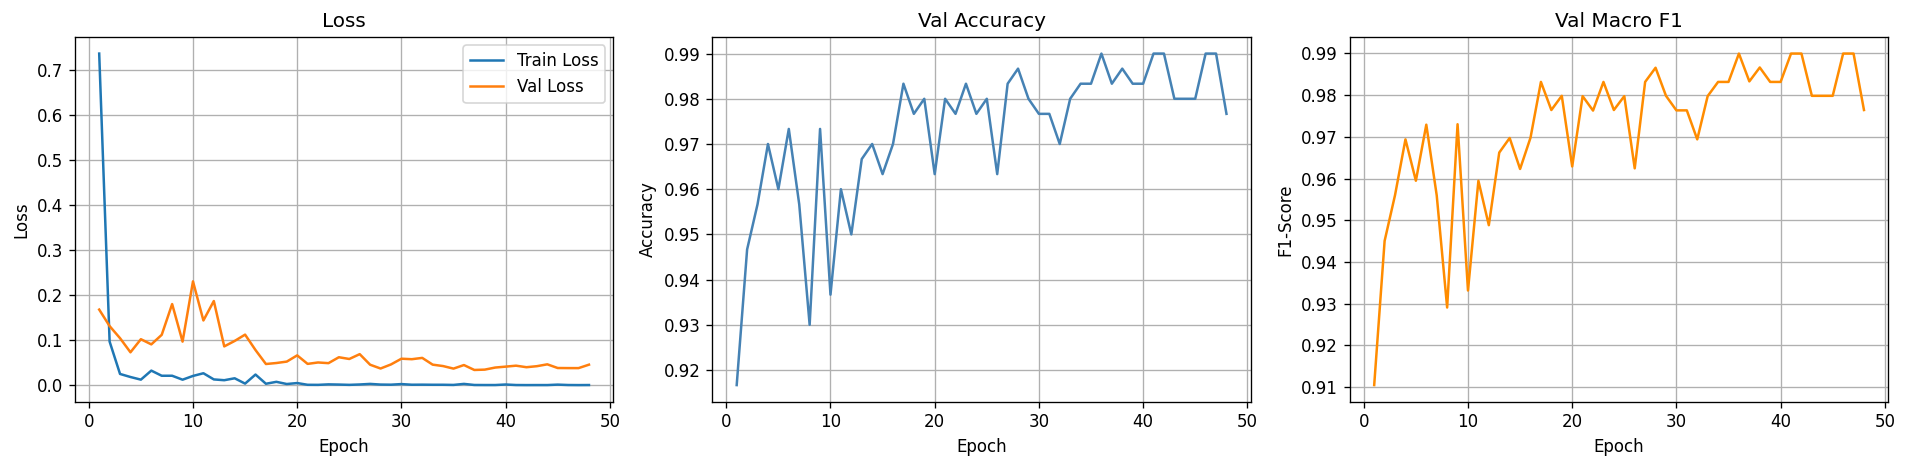

Training curves saved to /home/sammarv/quantum_corrosion/results/genomic_conv_hybrid_qnn/training_curves.png


In [8]:
# ==========================================
# 8. TRAINING CURVES
# ==========================================
ep_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep_range, history['train_loss'], label='Train Loss')
axes[0].plot(ep_range, history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ep_range, history['val_acc'], color='steelblue')
axes[1].set_title('Val Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

axes[2].plot(ep_range, history['val_f1'], color='darkorange')
axes[2].set_title('Val Macro F1')
axes[2].set_ylabel('F1-Score')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=200)
plt.show()

print(f"Training curves saved to {OUT_DIR / 'training_curves.png'}")

In [9]:
# ==========================================
# 9. FINAL EVALUATION
# ==========================================
model.load_state_dict(best_weights)
model.eval()

final_preds, final_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        out = model(inputs)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        final_preds.extend(preds)
        final_targets.extend(targets.numpy())

final_preds = np.array(final_preds)
final_targets = np.array(final_targets)

final_acc = accuracy_score(final_targets, final_preds)
final_f1_macro = f1_score(final_targets, final_preds, average='macro')
final_f1_weighted = f1_score(final_targets, final_preds, average='weighted')

print('=' * 65)
print('FINAL HYBRID QNN EVALUATION — TEST SET (Genomic 5-class)')
print('=' * 65)
print(f'Overall Accuracy   : {final_acc:.4f}')
print(f'Macro F1-Score     : {final_f1_macro:.4f}')
print(f'Weighted F1-Score  : {final_f1_weighted:.4f}')
print('\n--- CLASSIFICATION REPORT ---')
print(classification_report(final_targets, final_preds,
                             target_names=LABEL_NAMES, digits=4))

FINAL HYBRID QNN EVALUATION — TEST SET (Genomic 5-class)
Overall Accuracy   : 0.9900
Macro F1-Score     : 0.9899
Weighted F1-Score  : 0.9899

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

Genomic_Species_0     0.9836    1.0000    0.9917        60
Genomic_Species_1     0.9677    1.0000    0.9836        60
Genomic_Species_2     1.0000    1.0000    1.0000        60
Genomic_Species_3     1.0000    1.0000    1.0000        60
Genomic_Species_4     1.0000    0.9500    0.9744        60

         accuracy                         0.9900       300
        macro avg     0.9903    0.9900    0.9899       300
     weighted avg     0.9903    0.9900    0.9899       300



Saved → /home/sammarv/quantum_corrosion/results/genomic_conv_hybrid_qnn/confusion_matrix.png


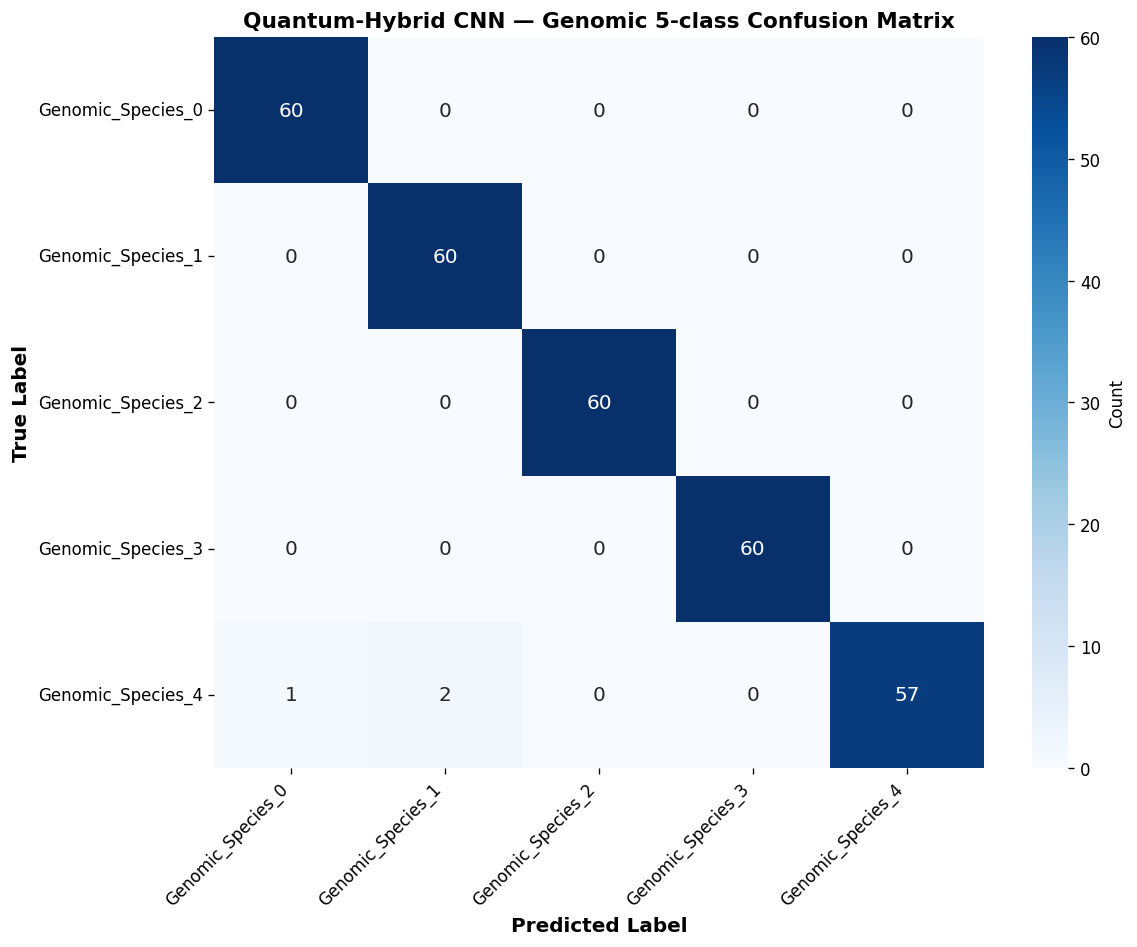

In [10]:
# ==========================================
# 10. CONFUSION MATRIX VISUALIZATION
# ==========================================
try:
    import seaborn as sns
    cm = confusion_matrix(final_targets, final_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                annot_kws={'size': 12}, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title('Quantum-Hybrid CNN — Genomic 5-class Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
    print(f'Saved → {OUT_DIR}/confusion_matrix.png')
    plt.show()
except ImportError:
    print("Seaborn not available. Showing raw confusion matrix.")
    cm = confusion_matrix(final_targets, final_preds)
    print('Confusion matrix (rows=true, cols=pred):')
    print(cm)

In [11]:
# ==========================================
# 11. SAVE RESULTS SUMMARY
# ==========================================
summary = {
    'model': 'ConvolutionalHybridQNN',
    'dataset': f'Genomic 5-class ({", ".join(LABEL_NAMES)})',
    'architecture': {
        'n_qubits': n_qubits,
        'n_layers': n_layers,
        'ansatz': 'BasicEntanglerLayers',
        'angle_scaling': '2*pi',
        'fusion': 'QuantumGuidedFusion (FiLM + gate)',
    },
    'hyperparams': {
        'lr': lr,
        'weight_decay': weight_decay,
        'batch_size': batch_size,
        'epochs_patience': patience,
        'epochs_trained': len(history['train_loss']),
    },
    'results': {
        'accuracy': float(final_acc),
        'f1_macro': float(final_f1_macro),
        'f1_weighted': float(final_f1_weighted),
        'best_val_f1': float(best_f1),
    },
    'classes': LABEL_NAMES,
    'data_info': {
        'total_samples': int(len(X_all)),
        'train_samples': int(len(X_train_np)),
        'test_samples': int(len(X_test_np)),
        'train_class_dist': {str(k): int(v) for k, v in enumerate(np.bincount(y_train_np))},
        'test_class_dist': {str(k): int(v) for k, v in enumerate(np.bincount(y_test_np))},
    }
}

with open(OUT_DIR / 'results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 70)
print('RESULTS SUMMARY')
print('=' * 70)
print(f'Model: {summary["model"]}')
print(f'Dataset: {summary["dataset"]}')
print(f'Test Accuracy: {final_acc:.4f}')
print(f'Test Macro F1: {final_f1_macro:.4f}')
print(f'Best Val F1: {best_f1:.4f}')
print(f'Epochs trained: {len(history["train_loss"])}')
print(f'\nCheckpoint: {OUT_DIR}/conv_hybrid_qnn_best.pt')
print(f'Summary: {OUT_DIR}/results_summary.json')
print(f'Training curves: {OUT_DIR}/training_curves.png')
print(f'Confusion matrix: {OUT_DIR}/confusion_matrix.png')
print('\n✓ Model training and evaluation complete!')

RESULTS SUMMARY
Model: ConvolutionalHybridQNN
Dataset: Genomic 5-class (Genomic_Species_0, Genomic_Species_1, Genomic_Species_2, Genomic_Species_3, Genomic_Species_4)
Test Accuracy: 0.9900
Test Macro F1: 0.9899
Best Val F1: 0.9899
Epochs trained: 48

Checkpoint: /home/sammarv/quantum_corrosion/results/genomic_conv_hybrid_qnn/conv_hybrid_qnn_best.pt
Summary: /home/sammarv/quantum_corrosion/results/genomic_conv_hybrid_qnn/results_summary.json
Training curves: /home/sammarv/quantum_corrosion/results/genomic_conv_hybrid_qnn/training_curves.png
Confusion matrix: /home/sammarv/quantum_corrosion/results/genomic_conv_hybrid_qnn/confusion_matrix.png

✓ Model training and evaluation complete!
